# 3 种 $W^R$ 积分策略的收敛性示例

同一多层基底 + 球形粒子（球心高度 $z$，半径 $R(z)=z$，球底贴在膜系上表面）、固定 $z$，逐步增大积分区间/采样规模，观察三种算法是否收敛到同一 $\max_{ij}|W^R_{ij}|$，并在收敛参数下画出有效 T 矩阵 $T_{\mathrm{eff}}$。

| 列 | 内容 | 横坐标 | 纵坐标 |
|---|---|---|---|
| 左 | 围道局部放大 + 极点（**每行自适应 Im 轴**） | $\mathrm{Re}(n_{\mathrm{eff}})$ | $\mathrm{Im}(n_{\mathrm{eff}})$ |
| 中 | Sommerfeld / residue | $n_{\mathrm{eff,max}}$ | $\max|W_{ij}|$ |
| 右 | Gauss–Laguerre | $n_x$ | $\max|W_{ij}|$ |

$z \in \{10^{-3},10^{-2},10^{-1},1,10,10^{2},10^{3}\}$（共 7 档）。

**运行前提**（在 `simulation_core/`）：

```bash
source scripts/init-simulation-build-env.sh
export LD_LIBRARY_PATH="$PWD/build:${LD_LIBRARY_PATH:-}"
export PYTHONPATH="$PWD/build:$PWD/simulation_plugins:${PYTHONPATH:-}"
```


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 120,
})

HERE = Path.cwd().resolve()
ROOT = None
for p in [HERE, *HERE.parents]:
    if (p / 'scripts' / 'init-simulation-build-env.sh').exists() and (p / 'build' / 'simulation.so').exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError('Cannot locate simulation_core root')

sys.path[:0] = [str(ROOT / 'build'), str(ROOT / 'simulation_plugins')]
os.environ['LD_LIBRARY_PATH'] = str(ROOT / 'build') + os.pathsep + os.environ.get('LD_LIBRARY_PATH', '')

import simulation as sim

print('ROOT =', ROOT)
print('wr_quadrature =', list(sim.wr_quadrature.names.keys()))


ROOT = /home/like/repos/simulation_toykits/simulation_core
wr_quadrature = ['sommerfeld', 'gauss_laguerre', 'residue_series']


## 物理模型与扫描参数

### 几何

- **基底（多层）**：从上到下 ambient → film → film → substrate（薄膜带吸收，导模极点离开实轴）
  - ambient：$n=1$（半无限）
  - film1：$n=1.6+0.01\mathrm{i}$，厚度 $d=40$
  - film2：$n=2.0+0.01\mathrm{i}$，厚度 $d=30$
  - substrate：$n=1.5$（半无限）
- **粒子**：均匀介质球，$n_p=1.5$；球心在反射平面正上方 $(0,0,z)$，**半径随高度取 $R(z)=z$**，使球底始终贴在膜系上表面、不穿入薄膜
- **波长 / 多极截断**：$\lambda=500$，$l_{\max}=m_{\max}=2$（矩阵维数 $N=16$）

吸收使导模 $n_{\mathrm{eff}}$ 具有 $\mathrm{Im}>0$，residue 路径会对这些极点做留数减除。

$W^R(z)$ 依赖基底与球心高度；$T=T(R(z))$ 为对应尺寸的自由空间 Mie/NFMDS T 矩阵；
$M=I-TW^R$，$T_{\mathrm{eff}}=M^{-1}T$。

度量：$\max_{ij}|W^R_{ij}|$。公平收敛扫描使用 `auto_neff_cap_from_z=0`。


In [2]:
wl = 500.0
n_med = 1.0
l_max = m_max = 2
k_med = 2.0 * np.pi * n_med / wl + 0j

# multilayer substrate (weak absorption → guided poles leave the real axis)
k_abs = 0.01
stack = [
    sim.make_layer_from_nk_d(1.0 + 0j, 0.0, 'amb'),
    sim.make_layer_from_nk_d(1.6 + 1j * k_abs, 40.0, 'f1'),
    sim.make_layer_from_nk_d(2.0 + 1j * k_abs, 30.0, 'f2'),
    sim.make_layer_from_nk_d(1.5 + 0j, 0.0, 'sub'),
]

# sphere: R(z)=z so bottom sits on stack top (never intersects films)
n_part = 1.5
mat_part = sim.share_material_d(sim.material_d.from_nk(n_part + 0j, 'part'))

def R_of_z(z):
    """Radius such that sphere bottom touches the ambient/film interface."""
    return float(z)

def free_T_for_R(R):
    sphere = sim.make_sphere_shape_d(float(R), [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], mat_part)
    return np.asarray(sim.compute_nfmds_tmatrix_d(sphere, wl, n_med + 0j, l_max), dtype=complex)

# 1e-3 ... 1e3，共 7 档（每档球半径 R=z）
z_list = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
nx_list = [24, 48, 64, 96, 128]

def neff_scan_for_z(z):
    if z <= 1e-2:
        return [50.0, 200.0, 1000.0, 5000.0, 20000.0]
    if z <= 1e-1:
        return [50.0, 200.0, 1000.0, 5000.0, 8000.0]
    if z <= 1.0:
        return [20.0, 40.0, 80.0, 160.0, 320.0]
    return [10.0, 20.0, 40.0, 60.0, 80.0]

def neff_res_for_cap(cap):
    return 2e-3 if cap < 200 else max(5e-3, min(2.0, cap / 4000.0))

# Fair S/R compare: same indent depth; hard-cap neff_max (no silent z-extension)
neff_imag_s = 1e-3
neff_imag_r = 1e-3
wr_pole_im_max = 0.2
auto_neff_cap_from_z = 0  # -1 method-default; 0 force off; 1 force on (fair scan uses 0)

print('z_list =', z_list)
print('R(z)  =', [R_of_z(z) for z in z_list])
print('nx_list =', nx_list)
print(f'stack films k_abs={k_abs} (complex n)')
print(f'sphere: n={n_part}, R(z)=z (bottom on stack), center=(0,0,z)')


z_list = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
R(z)  = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
nx_list = [24, 48, 64, 96, 128]
stack films k_abs=0.01 (complex n)
sphere: n=1.5, R(z)=z (bottom on stack), center=(0,0,z)


## 计算 $\max|W_{ij}|$、围道与收敛 $T_{\mathrm{eff}}$

调用 `compute_layer_mediated_coupling_self_d` / `find_neff_poles_for_residue_d` / `*_neff_contour_d`。  
每个 $z$：先算 $T(R{=}z)$，再在 Sommerfeld 最大 `neff_max` 下保存 $W^R$，最后 $T_{\mathrm{eff}}=(I-TW^R)^{-1}T$。


In [3]:
def wr_matrix(quad, z, *, neff_max=0.0, neff_resolution=1e-2, nx=48, neff_imag=1e-2):
    W = np.asarray(sim.compute_layer_mediated_coupling_self_d(
        stack, k_med, wl, z, z, l_max, m_max,
        quad, neff_imag, float(neff_max), float(neff_resolution),
        int(nx), wr_pole_im_max, int(auto_neff_cap_from_z)), dtype=complex)
    return W

def wr_maxabs(quad, z, *, neff_max=0.0, neff_resolution=1e-2, nx=48, neff_imag=1e-2):
    W = wr_matrix(quad, z, neff_max=neff_max, neff_resolution=neff_resolution,
                  nx=nx, neff_imag=neff_imag)
    return float(np.max(np.abs(W))) if W.size else 0.0

def teff_from_W(T, W):
    M = np.eye(T.shape[0], dtype=complex) - T @ W
    return np.linalg.solve(M, T)

poles = np.asarray(sim.find_neff_poles_for_residue_d(stack, wl, wr_pole_im_max))
print('poles =', poles)

rows = []
paths = {}
W_conv = {}
T_free_z = {}
Teff_conv = {}

for z in z_list:
    R = R_of_z(z)
    T = free_T_for_R(R)
    T_free_z[z] = T

    caps = neff_scan_for_z(z)
    res = neff_res_for_cap(max(caps))
    print(f'z={z:g}  R={R:g}  neff_max={caps}  neff_res={res:g}  ||T||_F={np.linalg.norm(T):.4e}')

    for cap in caps:
        vs = wr_maxabs(sim.wr_quadrature.sommerfeld, z, neff_max=cap,
                       neff_resolution=res, neff_imag=neff_imag_s)
        vr = wr_maxabs(sim.wr_quadrature.residue_series, z, neff_max=cap,
                       neff_resolution=res, neff_imag=neff_imag_r)
        rows.append({'z': z, 'method': 'sommerfeld', 'x': cap, 'val': vs})
        rows.append({'z': z, 'method': 'residue', 'x': cap, 'val': vr})

    for nx in nx_list:
        vl = wr_maxabs(sim.wr_quadrature.gauss_laguerre, z, nx=nx)
        rows.append({'z': z, 'method': 'laguerre', 'x': float(nx), 'val': vl})

    cap_max = max(caps)
    W = wr_matrix(sim.wr_quadrature.sommerfeld, z, neff_max=cap_max,
                  neff_resolution=res, neff_imag=neff_imag_s)
    W_conv[z] = W
    Teff_conv[z] = teff_from_W(T, W)
    print(f'  converged: max|W|={np.max(np.abs(W)):.4e}  max|Teff|={np.max(np.abs(Teff_conv[z])):.4e}')

    neff_show = 5.0
    res_show = 2e-3
    # 左图必须用各自真实围道：S=固定 indent；R=极点自适应 indent（含留数路径）
    ps = np.asarray(sim.sommerfeld_neff_contour_d(
        stack, wl, neff_imag_s, neff_show, res_show))
    pr = np.asarray(sim.residue_neff_contour_d(
        stack, wl, z, neff_imag_r, neff_show, res_show, wr_pole_im_max,
        int(auto_neff_cap_from_z)))
    paths[z] = {'S': ps, 'R': pr, 'cap_max': cap_max, 'neff_show': neff_show}

print('done,', len(rows), 'samples')


poles = [1.50224912+0.00117744j]
z=0.001  R=0.001  neff_max=[50.0, 200.0, 1000.0, 5000.0, 20000.0]  neff_res=2  ||T||_F=6.7394e-16
  converged: max|W|=1.2500e+16  max|Teff|=3.8917e-16
z=0.01  R=0.01  neff_max=[50.0, 200.0, 1000.0, 5000.0, 20000.0]  neff_res=2  ||T||_F=6.7394e-13
  converged: max|W|=1.2050e+16  max|Teff|=4.6966e-13
z=0.1  R=0.1  neff_max=[50.0, 200.0, 1000.0, 5000.0, 8000.0]  neff_res=2  ||T||_F=6.7394e-10
  converged: max|W|=8.3545e+15  max|Teff|=3.8953e-10
z=1  R=1  neff_max=[20.0, 40.0, 80.0, 160.0, 320.0]  neff_res=0.08  ||T||_F=6.7394e-07
  converged: max|W|=2.2393e+14  max|Teff|=4.0548e-07
z=10  R=10  neff_max=[10.0, 20.0, 40.0, 60.0, 80.0]  neff_res=0.002  ||T||_F=6.7430e-04
  converged: max|W|=7.9408e+04  max|Teff|=3.9592e-04
z=100  R=100  neff_max=[10.0, 20.0, 40.0, 60.0, 80.0]  neff_res=0.002  ||T||_F=5.9881e-01
  converged: max|W|=1.9866e+00  max|Teff|=3.8992e-01
z=1000  R=1000  neff_max=[10.0, 20.0, 40.0, 60.0, 80.0]  neff_res=0.002  ||T||_F=3.0703e-01
  con

## 作图 1：收敛性（围道 + $\max|W_{ij}|$）

- **左列围道**：固定局部窗口 `neff_show=5`、细步长画 indent（蓝：Sommerfeld `Im=-10^{-2}`；橙：residue 浅 indent `Im=-10^{-3}`）。与收敛扫描的大 `neff_max` 解耦，避免抽稀后路径消失。
- **中/右列**：$\max|W_{ij}|$；虚线为 S/R 最大区间参考极限。


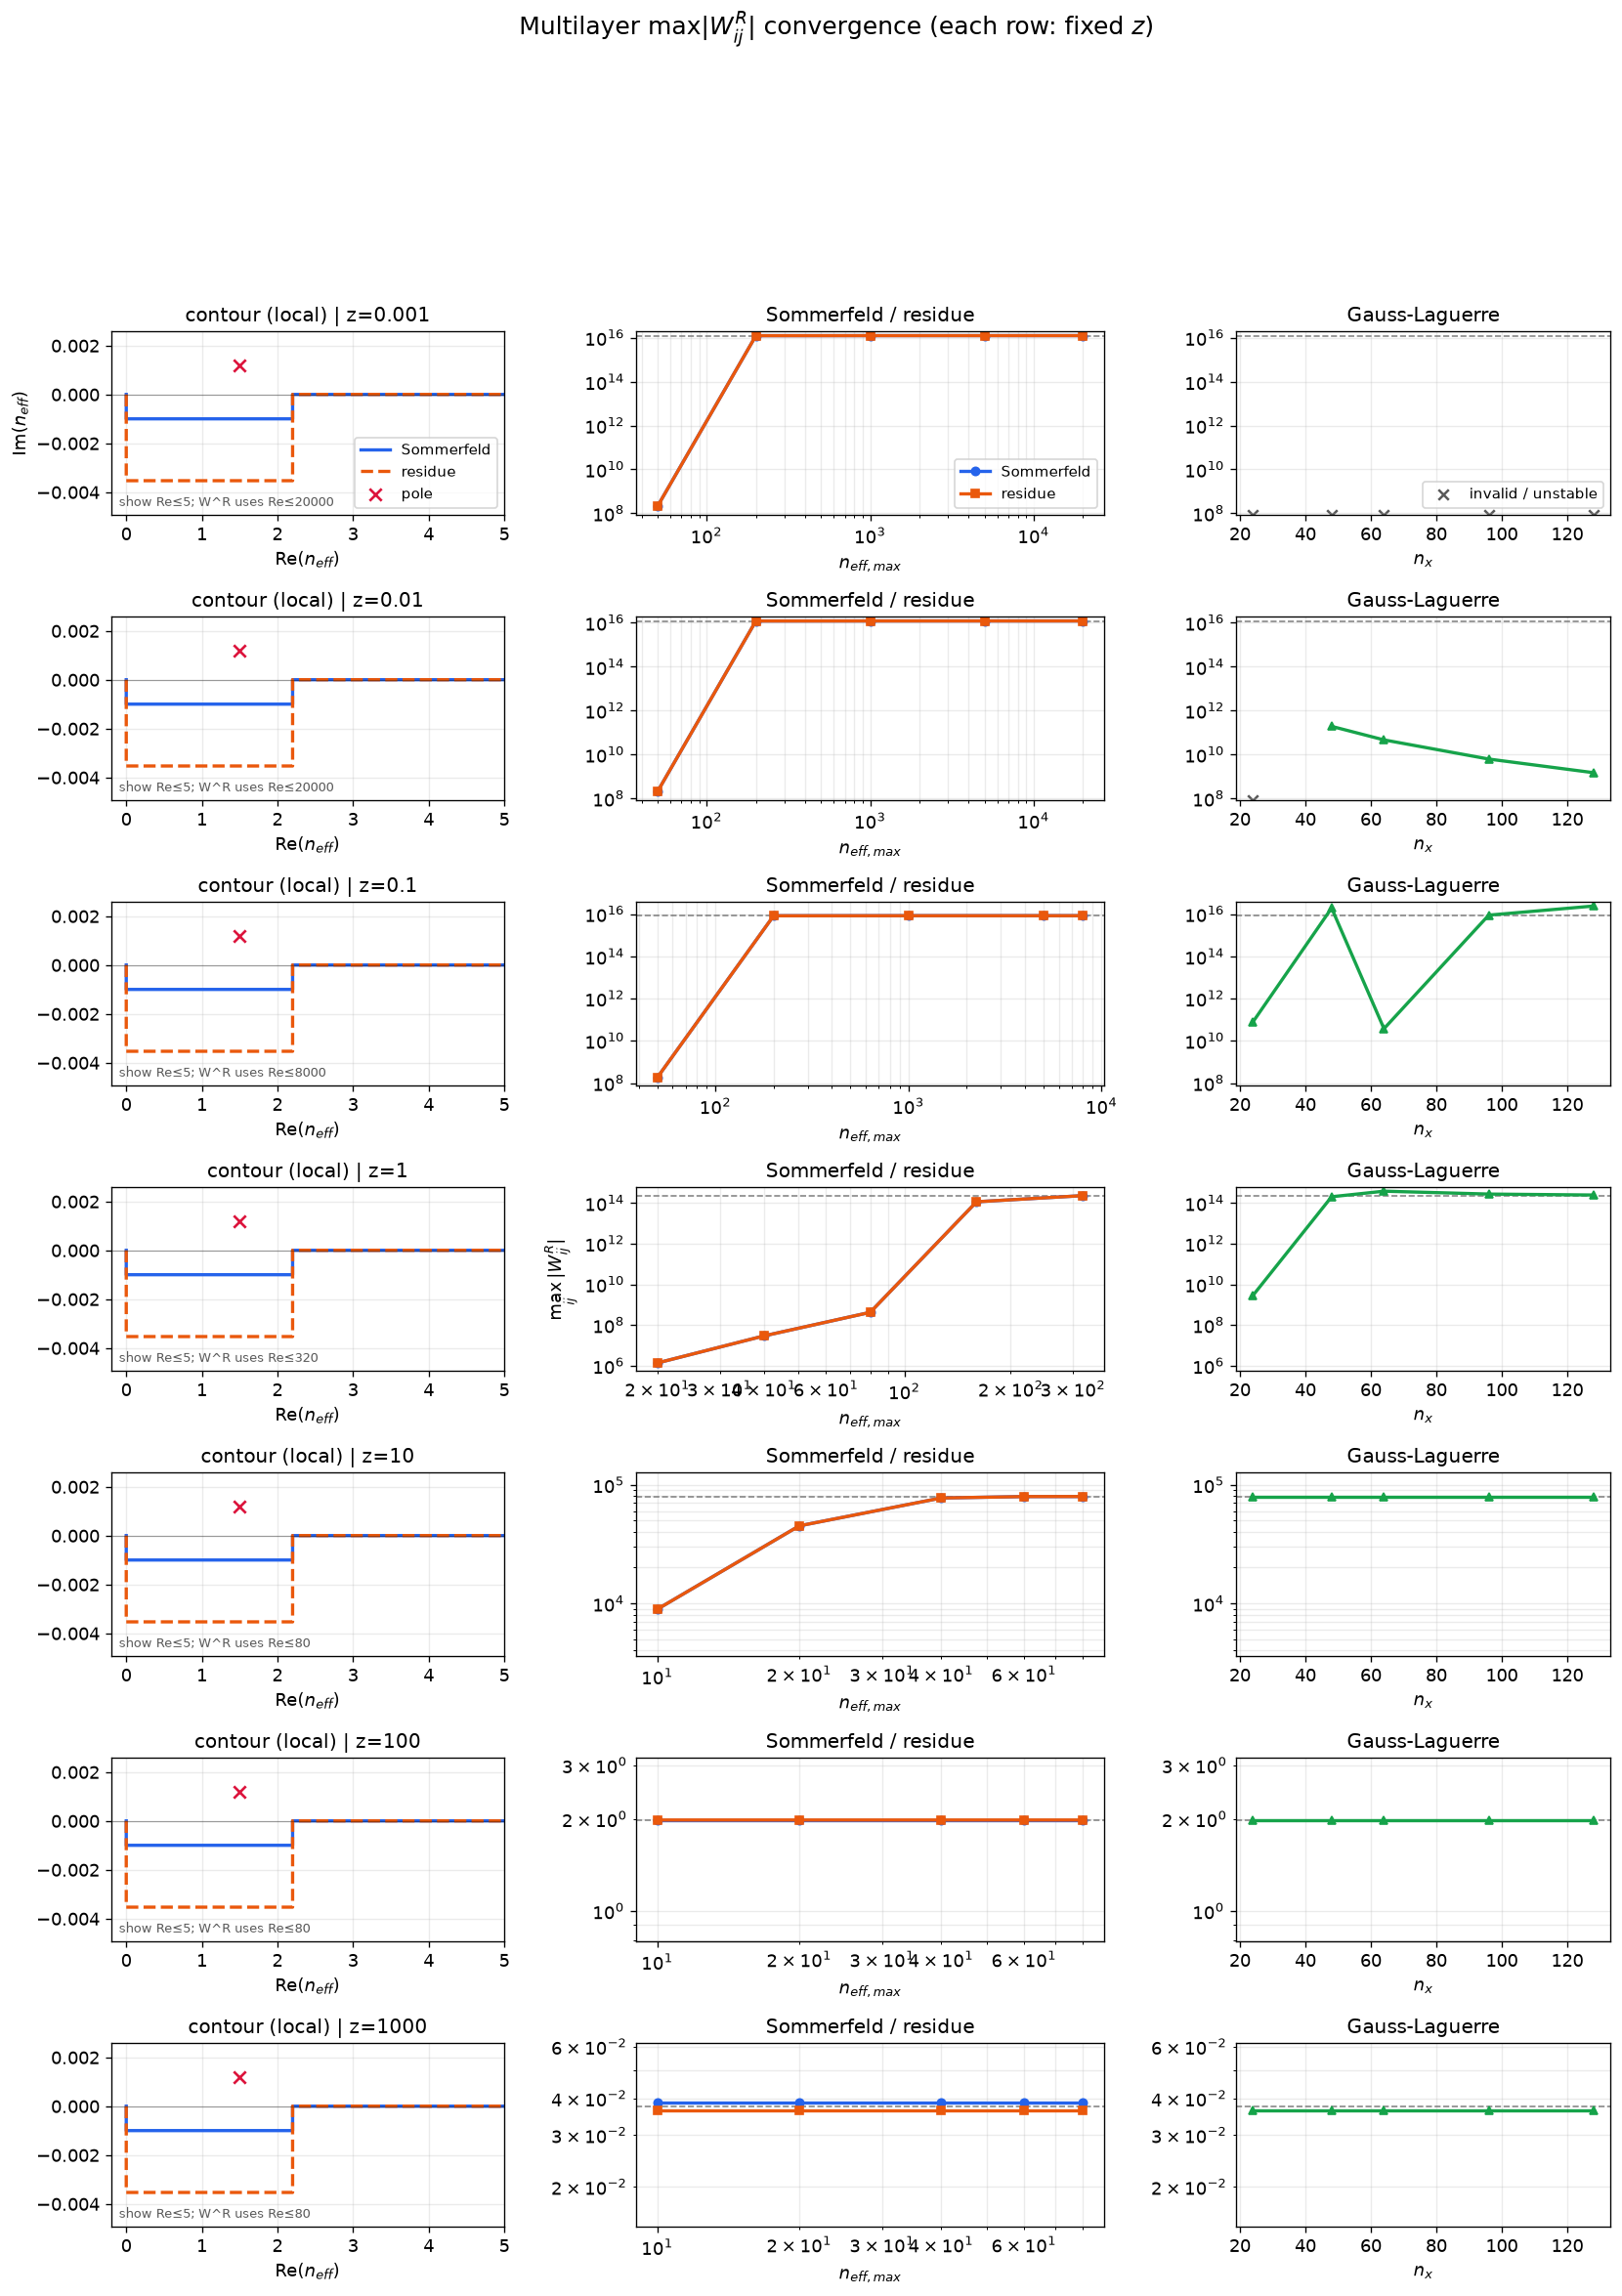

In [4]:
def pick(rows, z, method):
    xs, ys = [], []
    for r in rows:
        if r['z'] == z and r['method'] == method:
            xs.append(r['x']); ys.append(r['val'])
    order = np.argsort(xs)
    return np.asarray(xs)[order], np.asarray(ys)[order]

def sane_laguerre(v, ref):
    if not np.isfinite(v) or v <= 0:
        return np.nan
    if np.isfinite(ref) and ref > 0 and (v < ref * 1e-8 or v > ref * 50):
        return np.nan
    return v

colors = {'sommerfeld': '#2563eb', 'residue': '#ea580c', 'laguerre': '#16a34a'}
n = len(z_list)
fig = plt.figure(figsize=(16.5, 3.0 * n))
gs = fig.add_gridspec(n, 3, width_ratios=[1.05, 1.25, 1.0], wspace=0.32, hspace=0.55)

for row, z in enumerate(z_list):
    ax_path = fig.add_subplot(gs[row, 0])
    ax_sr = fig.add_subplot(gs[row, 1])
    ax_lg = fig.add_subplot(gs[row, 2])

    xs_s, ys_s = pick(rows, z, 'sommerfeld')
    xs_r, ys_r = pick(rows, z, 'residue')
    xs_l, ys_l = pick(rows, z, 'laguerre')
    ref = float(np.mean([ys_s[-1], ys_r[-1]])) if len(ys_s) and len(ys_r) else np.nan

    lg_y = np.array([sane_laguerre(v, ref) for v in ys_l], dtype=float)
    use = np.concatenate([ys_s, ys_r, lg_y[np.isfinite(lg_y)]])
    pos = use[use > 0]
    ylo = pos.min() * 0.4 if len(pos) else 1e-30
    yhi = pos.max() * 1.6 if len(pos) else 1.0

    for ax in (ax_sr, ax_lg):
        ax.set_yscale('log')
        ax.set_ylim(ylo, yhi)
        if np.isfinite(ref) and ref > 0:
            ax.axhline(ref, color='0.45', ls='--', lw=1.0, alpha=0.85)

    # ---- contour: local fine path (neff_show), adaptive Im ----
    ps, pr = paths[z]['S'], paths[z]['R']
    ax_path.plot(ps.real, ps.imag, color=colors['sommerfeld'], lw=2.0, label='Sommerfeld')
    ax_path.plot(pr.real, pr.imag, color=colors['residue'], lw=2.0, ls='--', label='residue')
    if poles.size:
        ax_path.scatter(poles.real, poles.imag, s=55, c='crimson', marker='x',
                        linewidths=1.6, zorder=5, label='pole')
    ax_path.axhline(0.0, color='k', lw=0.7, alpha=0.35)

    im_vals = np.concatenate([ps.imag, pr.imag])
    if poles.size:
        im_vals = np.concatenate([im_vals, poles.imag])
    im_min, im_max = float(np.min(im_vals)), float(np.max(im_vals))
    span = max(im_max - im_min, 2e-3)
    pad = 0.3 * span
    ax_path.set_ylim(im_min - pad, im_max + pad)
    ax_path.set_xlim(-0.2, max(4.5, float(paths[z].get('neff_show', 5.0))))
    ax_path.set_xlabel(r'Re($n_{eff}$)')
    if row == 0:
        ax_path.set_ylabel(r'Im($n_{eff}$)')
    ax_path.set_title(f'contour (local) | z={z:g}')
    ax_path.text(0.02, 0.05,
                 f"show Re≤{paths[z].get('neff_show', 5):g}; W^R uses Re≤{paths[z]['cap_max']:g}",
                 transform=ax_path.transAxes, fontsize=8, color='0.35')
    ax_path.grid(True, alpha=0.25)
    if row == 0:
        ax_path.legend(loc='lower right', fontsize=9)

    ax_sr.plot(xs_s, ys_s, 'o-', color=colors['sommerfeld'], lw=2.0, ms=5, label='Sommerfeld')
    ax_sr.plot(xs_r, ys_r, 's-', color=colors['residue'], lw=2.0, ms=5, label='residue')
    ax_sr.set_xscale('log')
    ax_sr.set_xlabel(r'$n_{eff,max}$')
    if row == n // 2:
        ax_sr.set_ylabel(r'$\max_{ij}|W^R_{ij}|$')
    ax_sr.set_title('Sommerfeld / residue')
    ax_sr.grid(True, which='both', alpha=0.25)
    if row == 0:
        ax_sr.legend(loc='lower right', fontsize=9)

    good = np.isfinite(lg_y)
    if np.any(good):
        ax_lg.plot(xs_l[good], lg_y[good], '^-', color=colors['laguerre'], lw=2.0, ms=5, label='Laguerre')
    if np.any(~good):
        ax_lg.scatter(xs_l[~good], np.full(np.count_nonzero(~good), ylo),
                      marker='x', color='0.35', s=40, label='invalid / unstable')
    ax_lg.set_xlabel(r'$n_x$')
    ax_lg.set_title('Gauss-Laguerre')
    ax_lg.grid(True, which='both', alpha=0.25)
    if row == 0:
        ax_lg.legend(loc='lower right', fontsize=9)

fig.suptitle(r'Multilayer $\max|W^R_{ij}|$ convergence (each row: fixed $z$)', fontsize=15, y=1.01)
plt.show()


## 作图 2：收敛参数下的有效 T 矩阵

对每个 $z$（对应 $R=z$ 的球贴在膜系上），取 Sommerfeld 最大 `neff_max` 下的 $W^R$，计算
$T_{\mathrm{eff}}=(I-TW^R)^{-1}T$，画出 $|T|$（该尺寸自由空间）与 $|T_{\mathrm{eff}}|$。


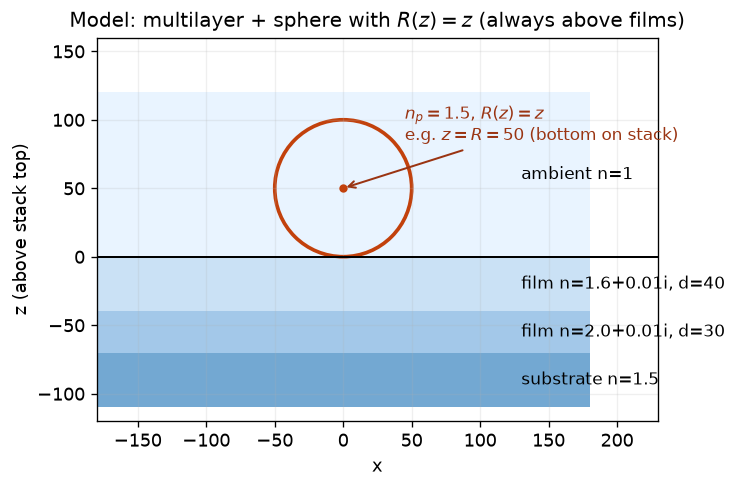

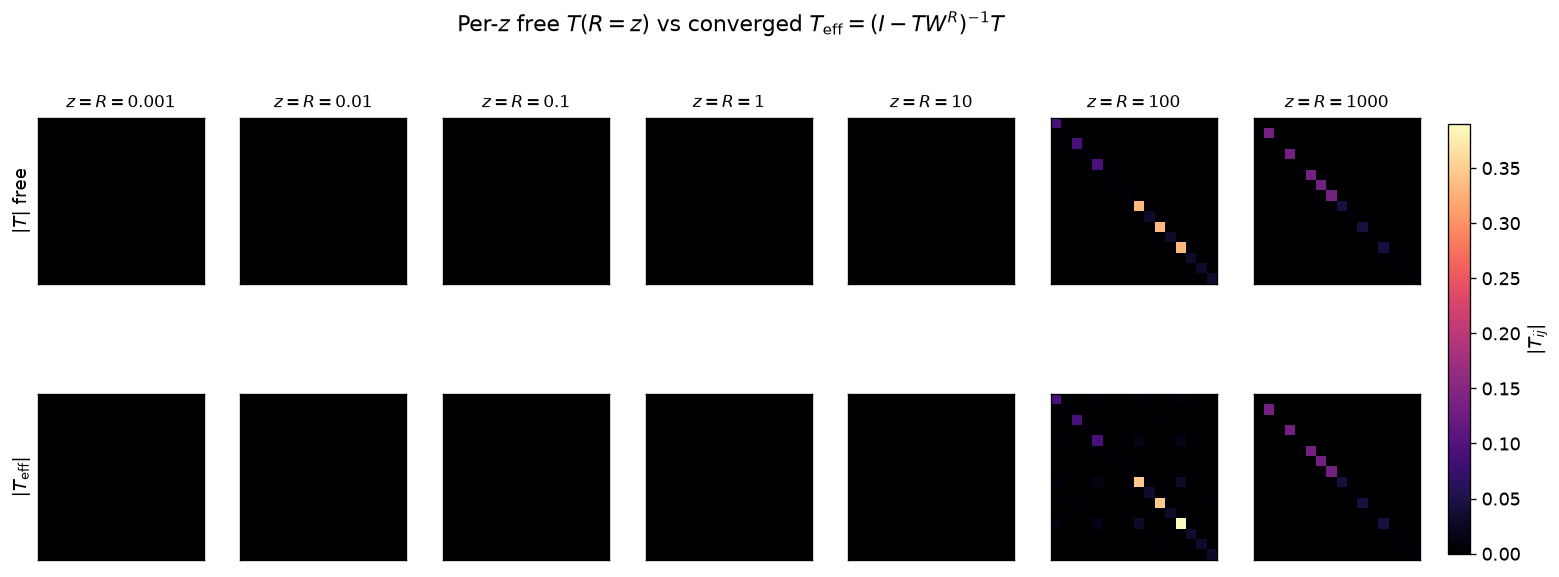

       z=R        max|W|       ||T||_F     max|Teff|    ||Teff||_F
     0.001    1.2500e+16    6.7394e-16    3.8917e-16    6.7398e-16
      0.01    1.2050e+16    6.7394e-13    4.6966e-13    7.2345e-13
       0.1    8.3545e+15    6.7394e-10    3.8953e-10    5.5063e-10
         1    2.2393e+14    6.7394e-07    4.0548e-07    5.6278e-07
        10    7.9408e+04    6.7430e-04    3.9592e-04    5.5675e-04
       100    1.9866e+00    5.9881e-01    3.8992e-01    6.5179e-01
      1000    3.8621e-02    3.0703e-01    1.3350e-01    3.0733e-01


In [5]:
# --- geometry sketch: R(z)=z, sphere sits on stack ---
fig_g, ax_g = plt.subplots(figsize=(8.5, 4.2))
ys = [120, 0, -40, -70, -110]
ns_lbl = [r'ambient n=1',
          rf'film n=1.6+{k_abs:g}i, d=40',
          rf'film n=2.0+{k_abs:g}i, d=30',
          'substrate n=1.5']
colors_L = ['#e8f4ff', '#c7e0f5', '#9ec5e8', '#6ba3d0']
for i, (y0, y1) in enumerate(zip(ys[:-1], ys[1:])):
    ax_g.fill_between([-180, 180], y1, y0, color=colors_L[i], alpha=0.95, lw=0)
    ax_g.text(130, 0.5 * (y0 + y1), ns_lbl[i], va='center', fontsize=10)
ax_g.axhline(0.0, color='k', lw=1.2)

z_demo = 50.0
R_demo = R_of_z(z_demo)
circ = plt.Circle((0.0, z_demo), R_demo, fill=False, ec='#c2410c', lw=2.2)
ax_g.add_patch(circ)
ax_g.plot([0], [z_demo], 'o', color='#c2410c', ms=4)
ax_g.annotate(
    rf'$n_p={n_part}$, $R(z)=z$'+'\n'+rf'e.g. $z=R={z_demo:g}$ (bottom on stack)',
    xy=(0, z_demo), xytext=(45, z_demo + 35),
    fontsize=10, color='#9a3412',
    arrowprops=dict(arrowstyle='->', color='#9a3412', lw=1.2))
ax_g.set_xlim(-180, 230)
ax_g.set_ylim(-120, 160)
ax_g.set_aspect('equal')
ax_g.set_xlabel('x')
ax_g.set_ylabel('z (above stack top)')
ax_g.set_title(r'Model: multilayer + sphere with $R(z)=z$ (always above films)')
ax_g.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- |T(R)| and |T_eff(z)| for each z ---
# two rows: free T(R=z) and Teff; columns = z
n = len(z_list)
fig_t, axes = plt.subplots(2, n, figsize=(2.2 * n, 5.2),
                           gridspec_kw=dict(wspace=0.22, hspace=0.35))

vmax = max(
    max(np.max(np.abs(T_free_z[z])) for z in z_list),
    max(np.max(np.abs(Teff_conv[z])) for z in z_list),
    1e-16,
)

for col, z in enumerate(z_list):
    for row, M in enumerate((T_free_z[z], Teff_conv[z])):
        ax = axes[row, col]
        im = ax.imshow(np.abs(M), origin='upper', cmap='magma',
                       vmin=0.0, vmax=vmax, aspect='equal')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(rf'$z=R={z:g}$', fontsize=10)
        if col == 0:
            ax.set_ylabel(r'$|T|$ free' if row == 0 else r'$|T_{\mathrm{eff}}|$', fontsize=11)

fig_t.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02,
               label=r'$|T_{ij}|$')
fig_t.suptitle(r'Per-$z$ free $T(R{=}z)$ vs converged $T_{\mathrm{eff}}=(I-TW^R)^{-1}T$',
               fontsize=13, y=1.02)
plt.show()

print(f'{"z=R":>10}  {"max|W|":>12}  {"||T||_F":>12}  {"max|Teff|":>12}  {"||Teff||_F":>12}')
for z in z_list:
    print(f'{z:10g}  {np.max(np.abs(W_conv[z])):12.4e}  {np.linalg.norm(T_free_z[z]):12.4e}  '
          f'{np.max(np.abs(Teff_conv[z])):12.4e}  {np.linalg.norm(Teff_conv[z]):12.4e}')


## 读图

### 1. 模型

多层吸收膜系 + ambient 中贴膜球（$R=z$）。反射平面在 ambient–film1；$z$ 为球心高度。

### 2. 收敛性图（作图 1）

- **左列**：Sommerfeld 固定 indent；residue 为极点自适应围道。红叉为复导模极点。
- **中列**：公平硬截断下 S/R 常几乎重叠（同一物理量）。
- **右列**：Laguerre；小 $z$ 易失效。

### 3. 有效 T 热图（作图 2）

上行自由空间 $|T(R{=}z)|$，下行收敛 $|T_{\mathrm{eff}}|$。

### 4. 默认配置对照

贴膜粒子（$z=R=10$）上，Sommerfeld 方法默认截断过短会失手；residue 默认带 $z$ 拉长可 cover；对照真值取 **Sommerfeld 大 `neff_max` 收敛结果**。


## 默认配置对照：贴膜粒子上 Sommerfeld 失手、residue 仍可用

方法默认（`auto_neff_cap_from_z=-1` → 按方法）：

| | Sommerfeld | residue_series |
|---|---|---|
| `neff_imag` | $10^{-2}$ | $10^{-3}$（有极点时 indent 由极点自适应） |
| `neff_max` | $0$（仅按膜系 $n$ 截断） | $0$，但 **默认开启** $z$ 启发式拉长 |
| `auto_neff_cap_from_z` | **false** | **true** |

因此对**贴膜近场粒子**（小 $z=R$），只换 `quad`、其余用默认时：Sommerfeld 截断过短会严重偏低；residue 会按 $z$ 自动把积分区间拉够，并处理复极点。

下面取 $z=R=10$（球底贴膜），直接对比默认调用。


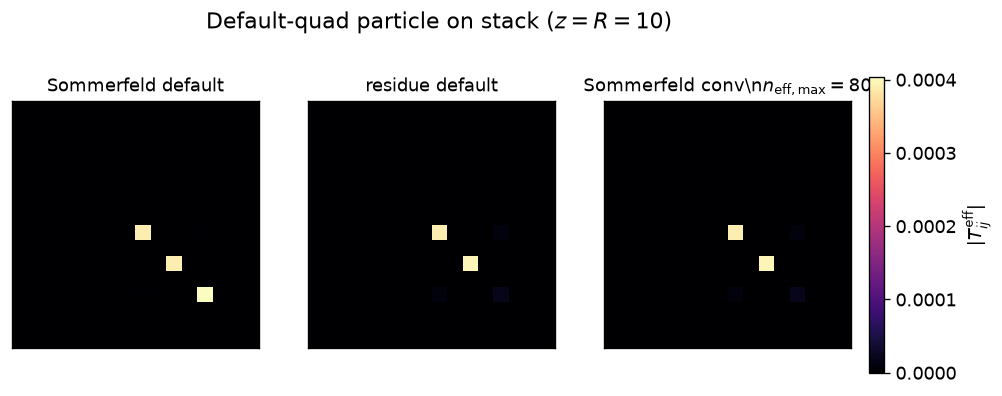

particle: n_p=1.5, R=z=10, stack films k_abs=0.01
poles = [1.50224912+0.00117744j]
                             max|W|   ||Teff||_F  relW to ref      relTeff
Sommerfeld default       1.3344e+02   6.8301e-04    9.983e-01    7.608e-01
residue default          7.9408e+04   5.5673e-04    7.067e-05    6.336e-05
Sommerfeld conv (nmax=80)   7.9408e+04   5.5675e-04            0            0


In [6]:
# 贴膜粒子：z = R = 10，只改 quad，其余走方法默认
z_p = 10.0
R_p = R_of_z(z_p)
T_p = free_T_for_R(R_p)

def wr_default(quad):
    """Omit auto_neff_cap_from_z (=-1) → method default (S: off, R: on)."""
    return np.asarray(sim.compute_layer_mediated_coupling_self_d(
        stack, k_med, wl, z_p, z_p, l_max, m_max, quad), dtype=complex)

Ws = wr_default(sim.wr_quadrature.sommerfeld)
Wr = wr_default(sim.wr_quadrature.residue_series)

# 参考：Sommerfeld 在充分大 neff_max 下收敛后的结果（硬截断，关 z-auto）
neff_max_conv = 80.0  # z=10 时与 20/(k0·2z) 同量级；扫过平台即可
Wref = np.asarray(sim.compute_layer_mediated_coupling_self_d(
    stack, k_med, wl, z_p, z_p, l_max, m_max, sim.wr_quadrature.sommerfeld,
    1e-2, neff_max_conv, 2e-3, 48, wr_pole_im_max, 0), dtype=complex)

def teff(T, W):
    return np.linalg.solve(np.eye(T.shape[0], dtype=complex) - T @ W, T)

Ts, Tr, Tref = teff(T_p, Ws), teff(T_p, Wr), teff(T_p, Wref)

def rel(A, B):
    return float(np.linalg.norm(A - B) / max(np.linalg.norm(B), 1e-30))

print(f'particle: n_p={n_part}, R=z={z_p:g}, stack films k_abs={k_abs}')
print(f'poles = {np.asarray(sim.find_neff_poles_for_residue_d(stack, wl, wr_pole_im_max))}')
print(f'{"":22} {"max|W|":>12} {"||Teff||_F":>12} {"relW to ref":>12} {"relTeff":>12}')
print(f'{"Sommerfeld default":22} {np.max(np.abs(Ws)):12.4e} {np.linalg.norm(Ts):12.4e} {rel(Ws,Wref):12.3e} {rel(Ts,Tref):12.3e}')
print(f'{"residue default":22} {np.max(np.abs(Wr)):12.4e} {np.linalg.norm(Tr):12.4e} {rel(Wr,Wref):12.3e} {rel(Tr,Tref):12.3e}')
label_ref = f'Sommerfeld conv (nmax={neff_max_conv:g})'
print(f'{label_ref:22} {np.max(np.abs(Wref)):12.4e} {np.linalg.norm(Tref):12.4e} {"0":>12} {"0":>12}')

# |Teff| heatmaps
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2))
vmax = max(np.max(np.abs(Ts)), np.max(np.abs(Tr)), np.max(np.abs(Tref)), 1e-16)
for ax, M, tit in zip(axes, [Ts, Tr, Tref],
                      [r'Sommerfeld default', r'residue default', rf'Sommerfeld conv\n$n_{{\mathrm{{eff,max}}}}={neff_max_conv:g}$']):
    im = ax.imshow(np.abs(M), origin='upper', cmap='magma', vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(tit, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02, label=r'$|T^{\mathrm{eff}}_{ij}|$')
fig.suptitle(rf'Default-quad particle on stack ($z=R={z_p:g}$)', y=1.05)
plt.show()


## 三种方法的异同

| 方法 | 积分形式 | 横坐标 | 极点/导模 | 小 $z$ |
|---|---|---|---|---|
| **Sommerfeld** | 复平面围道 | `neff_max` | 围道绕行，不做留数减除 | 区间够大即可平台收敛 |
| **residue_series** | 留数减除 + 极点围道 | `neff_max` | 自动求极点；上半平面做减除；**实轴导模只驱动 indent** | 与 Sommerfeld 同平台（公平截断下） |
| **Gauss–Laguerre** | 变量替换 + Laguerre 求积 | `nx_laguerre` | 无极点搜索 | $q\propto z$ 小时条件差，收敛更慢/易失效 |

### 什么情况下用什么方法

| 场景 | 推荐 | 原因 |
|---|---|---|
| **默认 / 生产路径** | Sommerfeld | 不依赖极点搜索，围道 indent 即可绕开实轴导模；调大 `neff_max` 后小 $z$ 也能稳定到平台 |
| **要核对极点物理 / 交叉验证** | residue_series（对照 Sommerfeld） | 显式求出导模/复极点并做留数减除；与 Sommerfeld 在充分大区间应对到同一 $\max\|W\|$，便于排查“是积分发散还是物理放大” |
| **球心较高、近场衰减快**（大致 $z\gtrsim 10\sim 10^{2}$，视波长与膜系而定） | Gauss–Laguerre 可优先试 | 实轴变量替换后固定节点求积，实现简单、参数主要是 $n_x$，大 $z$ 时往往更快收敛 |
| **近场 / 贴膜**（小 $z$，本例 $R=z$） | **不要**单独依赖 Laguerre | $q\propto z$ 过小使被积函数病态；应用 Sommerfeld 或 residue，并把 `neff_max` 扫到平台 |
| **膜系导模丰富、关心模式贡献** | residue_series | 极点列表本身就是物理诊断；留数项可单独讨论导模通道 |
| **只需一条稳健曲线、少调参** | Sommerfeld | 主要旋钮是 `neff_max` + `neff_imag`；无需极点搜索 |
| **有导模且希望 indent 少操心** | residue_series | 极点（含实轴）自动定 indent；仍建议关掉 `auto_neff_cap_from_z` 做截断扫描 |

### 各方法的好处（一句话）

- **Sommerfeld**：通用底板——近场远场都能靠加大截断收敛，最适合作为“真值参考”。
- **residue_series**：把奇点从积分里拆出来，物理可读性更好，并与 Sommerfeld 互证。
- **Gauss–Laguerre**：大 $z$ 时省围道、省极点，节点数上去即可；近场则应降级为辅助对照，不以它裁决是否发散。

### 实用建议

1. 先用 **Sommerfeld** 扫 `neff_max` 看是否出平台。  
2. 用 **residue_series** 在同一截断下对照；两者汇合则可信。  
3. 大 $z$ 再开 **Laguerre** 作加速/交叉检查；小 $z$ 若 Laguerre 偏离平台，以 S/R 为准。


### 用户层：`neff_imag` 与 `auto_neff_cap_from_z`

| 项 | Sommerfeld | residue_series |
|---|---|---|
| **indent** | 需设 `neff_imag`（或 `NaN` 走自适应） | **有极点时自动**（含实轴导模，indent 下限约 $10^{-3}$）；无极点才用 `neff_imag` |
| **截断** | `neff_max`；`auto_neff_cap_from_z` 控制是否再与 $20/(k_0\cdot 2z)$ 取 max | 同左 |
| **收敛扫描** | 设 `auto_neff_cap_from_z=0` 且显式扫 `neff_max` | **同样**关闭自动拉长，否则小 $z$ 会“看起来更快收敛” |

本笔记对比曲线使用：`neff_imag_s = neff_imag_r = 10^{-3}`，`auto_neff_cap_from_z=0`。


### 方法默认的截断不对称（贴膜场景）

- **Sommerfeld 默认** `auto_neff_cap_from_z=false`：`neff_max=0` 时只按膜系 $n$ 截断 → **近场/贴膜粒子易严重低估**。
- **residue 默认** `auto_neff_cap_from_z=true`：按 $z$ 自动拉长 + 极点 $F_{\mathrm{reg}}$ → **默认可 cover 贴膜粒子**。
- 公平收敛扫描请显式设 `auto_neff_cap_from_z=0` 并扫同一 `neff_max`（本笔记作图 1 即如此）。
